# DLBCL external validation — JCO CCI additions
Inputs: committed output of `dlbcl_revision_A1_A3` (all cohorts as parquet/CSV) + `lenz-signatures` dataset.
**B1** signature-length vs transfer sweep (both directions) · **B2** path-end vs tuned cautionary analysis · **B3** Lenz reproduction figure + cross-platform implementation check · **B4** equivalence framing (does each CI exclude a ΔC ≥ 0.02 gain?)

In [1]:
import glob; print(sorted(glob.glob('/kaggle/input/**/*.csv', recursive=True) + glob.glob('/kaggle/input/**/*.parquet', recursive=True)))

['/kaggle/input/notebooks/lawin2593/dlbcl-notebook2/gse10846_clin.csv', '/kaggle/input/notebooks/lawin2593/dlbcl-notebook2/gse10846_expr.parquet', '/kaggle/input/notebooks/lawin2593/dlbcl-notebook2/gse181063_clin.csv', '/kaggle/input/notebooks/lawin2593/dlbcl-notebook2/gse181063_expr_genes.parquet', '/kaggle/input/notebooks/lawin2593/dlbcl-notebook2/gse181063_expr_probes.parquet', '/kaggle/input/notebooks/lawin2593/notebook775ab2dde8/gse10846_clin.csv', '/kaggle/input/notebooks/lawin2593/notebook775ab2dde8/gse10846_expr.parquet', '/kaggle/input/notebooks/lawin2593/notebook775ab2dde8/gse181063_clin_fixed.csv', '/kaggle/input/notebooks/lawin2593/notebook775ab2dde8/gse181063_expr_genes.parquet', '/kaggle/input/notebooks/lawin2593/notebook775ab2dde8/gse87371_clin.csv', '/kaggle/input/notebooks/lawin2593/notebook775ab2dde8/gse87371_clin_raw.csv', '/kaggle/input/notebooks/lawin2593/notebook775ab2dde8/gse87371_expr_genes.parquet']


In [2]:
!pip -q install scikit-survival lifelines
import pandas as pd, numpy as np, glob, os, sys, matplotlib.pyplot as plt
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from lifelines import KaplanMeierFitter
def find(n):
    h=glob.glob(f'/kaggle/input/**/{n}', recursive=True); return h[0] if h else None
expr_tr=pd.read_parquet(find("gse10846_expr.parquet")); clin_tr=pd.read_csv(find("gse10846_clin.csv"), index_col=0)
expr_val=pd.read_parquet(find("gse181063_expr_genes.parquet")); clin_val=pd.read_csv(find("gse181063_clin_fixed.csv"), index_col=0)
expr3g=pd.read_parquet(find("gse87371_expr_genes.parquet")); df3=pd.read_csv(find("gse87371_clin.csv"), index_col=0)
sys.path.append(os.path.dirname(find("lenz_signatures.py")))
from lenz_signatures import GCB_SYMBOLS, STROMAL1_SYMBOLS, STROMAL2_SYMBOLS, LENZ_ALIASES
print(expr_tr.shape, expr_val.shape, expr3g.shape)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.
(22880, 420) (20817, 1310) (22880, 223)


## Frames, populations, frozen models (identical to prior notebooks)

In [3]:
cv=clin_val.copy(); dfv=pd.DataFrame(index=cv.index)
dfv["time_yrs"]=pd.to_numeric(cv["os_followup_y"],errors="coerce"); dfv["event"]=pd.to_numeric(cv["os_status"],errors="coerce")
dfv["age"]=pd.to_numeric(cv["age_at_diagnosis"],errors="coerce"); dfv["ecog"]=pd.to_numeric(cv["performance_status_ecog"],errors="coerce")
dfv["stage"]=cv["stage"].astype(str).str.extract(r'(IV|III|II|I)')[0].map({"I":1,"II":2,"III":3,"IV":4})
dfv["ldh_raised"]=cv["ldh"].astype(str).str.lower().eq("raised").astype(float)
dfv.loc[~cv["ldh"].astype(str).str.lower().isin(["raised","normal"]),"ldh_raised"]=np.nan
dfv["extranodal"]=pd.to_numeric(cv["num_extranodal"],errors="coerce"); dfv["ipi_given"]=pd.to_numeric(cv["ipi_score"],errors="coerce")
dfv["coo"]=cv["pred_combine"]; dfv["qc_fail"]=pd.to_numeric(cv["qc_fail"],errors="coerce"); dfv["regimen"]=cv["firstline_regimen"]
dfv["curative"]=pd.to_numeric(cv["curative_intent"],errors="coerce"); dfv["dlbcl"]=cv["diagnostic_group"].astype(str).str.contains("DLBCL",na=False)
primary=(dfv["dlbcl"]&(dfv["qc_fail"]==0)&(dfv["curative"]==1)&dfv["regimen"].isin(["CHOP-R","CHOP-R/Bortezomib"])&dfv["time_yrs"].notna()&dfv["event"].notna())
val_ids=dfv.index[primary].intersection(expr_val.columns); yv=dfv.loc[val_ids]; eval_ids=val_ids[yv["ipi_given"].notna()]; ev=yv.loc[eval_ids]
keep3=df3["time_yrs"].notna()&df3["event"].notna()&df3["ipi_given"].notna()&~df3["coo"].astype(str).str.upper().isin(["PMBL"])
ids3=df3.index[keep3].intersection(expr3g.columns)
common_genes=expr_tr.index.intersection(expr_val.index)
tr=clin_tr[(clin_tr["rchop"]==1)&clin_tr["time_yrs"].notna()].copy(); tr_ids=tr.index.intersection(expr_tr.columns); tr=tr.loc[tr_ids]
y_tr=Surv.from_arrays(tr["event"].astype(bool),tr["time_yrs"])
g10=tr.index[tr["ipi"].notna()]
print("HMRN eval:",len(eval_ids),"| GSE10846 R-CHOP:",len(tr_ids),"(IPI:",len(g10),") | GSE87371:",len(ids3))

def boot_generic(e,t,s,ipi,n_boot=1000,seed=42):
    e,t,s,ipi=map(np.asarray,(e,t,s,ipi)); rng=np.random.default_rng(seed); ds=[]
    for _ in range(n_boot):
        i=rng.integers(0,len(e),len(e))
        try: ds.append(concordance_index_censored(e[i],t[i],s[i])[0]-concordance_index_censored(e[i],t[i],ipi[i])[0])
        except Exception: pass
    lo,hi=np.percentile(ds,[2.5,97.5]); return concordance_index_censored(e,t,s)[0],float(np.mean(ds)),lo,hi
def slope(e,t,s):
    return CoxPHSurvivalAnalysis().fit(np.asarray(s).reshape(-1,1),Surv.from_arrays(np.asarray(e).astype(bool),np.asarray(t))).coef_[0]

def cv_alpha(X,y,seed=42):
    pm=CoxnetSurvivalAnalysis(l1_ratio=0.9,alpha_min_ratio=0.01,n_alphas=50,max_iter=100000).fit(X,y); al=pm.alphas_
    cvs=np.full((5,len(al)),np.nan)
    for k,(tri,tei) in enumerate(KFold(5,shuffle=True,random_state=seed).split(X)):
        m=CoxnetSurvivalAnalysis(l1_ratio=0.9,alphas=al,max_iter=100000).fit(X[tri],y[tri])
        for j,a in enumerate(al):
            try: cvs[k,j]=concordance_index_censored(y[tei]["event"],y[tei]["time"],m.predict(X[tei],alpha=a))[0]
            except Exception: pass
    return pm, al, np.nanmean(cvs,axis=0)

HMRN eval: 552 | GSE10846 R-CHOP: 233 (IPI: 164 ) | GSE87371: 201


## B1 — Signature length vs external transfer (both directions)

In [4]:
def sweep(train_expr, train_ids, y_train, targets, label):
    Xg=train_expr.loc[common_genes,train_ids].T; top_=Xg.var().nlargest(2000).index
    X=StandardScaler().fit_transform(Xg[top_])
    pm,al,mc=cv_alpha(X,y_train)
    nz=np.array([(pm.coef_[:,j]!=0).sum() for j in range(len(al))])
    rows=[]; used=set()
    for target_n in [5,10,20,50,100,200,500]:
        j=int(np.argmin(np.abs(nz-target_n)))
        if nz[j]==0 or j in used: continue
        used.add(j); coef=pm.coef_[:,j]                       # frozen path coefficients, no refit
        rec={"direction":label,"n_genes":int(nz[j]),"alpha":al[j],"internalCV_C":mc[j]}
        for tname,(texpr,tids,tdf,ipicol) in targets.items():
            Xt=StandardScaler().fit_transform(texpr.reindex(top_).loc[:,tids].fillna(0).T)
            p=Xt@coef; e=tdf.loc[tids,"event"].astype(bool); t=tdf.loc[tids,"time_yrs"]; ipi=tdf.loc[tids,ipicol]
            c,d,lo,hi=boot_generic(e,t,p,ipi)
            rec[f"{tname}_C"]=c; rec[f"{tname}_dC"]=d; rec[f"{tname}_lo"]=lo; rec[f"{tname}_hi"]=hi; rec[f"{tname}_slope"]=slope(e,t,p)
        rows.append(rec); print(rec["direction"], rec["n_genes"], {k:round(v,3) for k,v in rec.items() if isinstance(v,float)})
    return pd.DataFrame(rows)

In [5]:
def sweep(train_expr, train_ids, y_train, targets, label):
    Xg=train_expr.loc[common_genes,train_ids].T; top_=Xg.var().nlargest(2000).index
    X=StandardScaler().fit_transform(Xg[top_])
    pm,al,mc=cv_alpha(X,y_train)
    nz=np.array([(pm.coef_[:,j]!=0).sum() for j in range(len(al))])
    rows=[]; used=set()
    for target_n in [5,10,20,50,100,200,500]:
        j=int(np.argmin(np.abs(nz-target_n)))
        if nz[j]==0 or j in used: continue
        used.add(j); coef=pm.coef_[:,j]
        rec={"direction":label,"n_genes":int(nz[j]),"alpha":al[j],"internalCV_C":mc[j]}
        for tname,(texpr,tids,tdf,ipicol) in targets.items():
            Xt=StandardScaler().fit_transform(texpr.reindex(top_).loc[:,tids].fillna(0).T)
            p=Xt@coef; e=tdf.loc[tids,"event"].astype(bool); t=tdf.loc[tids,"time_yrs"]; ipi=tdf.loc[tids,ipicol]
            c,d,lo,hi=boot_generic(e,t,p,ipi)
            rec[f"{tname}_C"]=c; rec[f"{tname}_dC"]=d; rec[f"{tname}_lo"]=lo; rec[f"{tname}_hi"]=hi; rec[f"{tname}_slope"]=slope(e,t,p)
        rows.append(rec); print(rec["direction"], rec["n_genes"], {k:round(v,3) for k,v in rec.items() if isinstance(v,float)})
    return pd.DataFrame(rows)

y_h=Surv.from_arrays(dfv.loc[val_ids,"event"].astype(bool),dfv.loc[val_ids,"time_yrs"])
trdf=tr.rename(columns={"ipi":"ipi_given"})
S1=sweep(expr_val,val_ids,y_h,{"GSE10846":(expr_tr,g10,trdf,"ipi_given"),"GSE87371":(expr3g,ids3,df3,"ipi_given")},"HMRN->Affy")
S2=sweep(expr_tr,tr_ids,y_tr,{"GSE181063":(expr_val,eval_ids,dfv,"ipi_given"),"GSE87371":(expr3g,ids3,df3,"ipi_given")},"GSE10846->ext")
S1.to_csv("/kaggle/working/sweep_hmrn_trained.csv",index=False); S2.to_csv("/kaggle/working/sweep_gse10846_trained.csv",index=False)

HMRN->Affy 7 {'alpha': np.float64(0.139), 'internalCV_C': np.float64(0.622), 'GSE10846_C': np.float64(0.627), 'GSE10846_dC': -0.072, 'GSE10846_lo': np.float64(-0.169), 'GSE10846_hi': np.float64(0.03), 'GSE10846_slope': np.float64(5.113), 'GSE87371_C': np.float64(0.598), 'GSE87371_dC': -0.19, 'GSE87371_lo': np.float64(-0.276), 'GSE87371_hi': np.float64(-0.102), 'GSE87371_slope': np.float64(3.902)}
HMRN->Affy 9 {'alpha': np.float64(0.116), 'internalCV_C': np.float64(0.637), 'GSE10846_C': np.float64(0.678), 'GSE10846_dC': -0.021, 'GSE10846_lo': np.float64(-0.114), 'GSE10846_hi': np.float64(0.071), 'GSE10846_slope': np.float64(3.352), 'GSE87371_C': np.float64(0.633), 'GSE87371_dC': -0.155, 'GSE87371_lo': np.float64(-0.239), 'GSE87371_hi': np.float64(-0.073), 'GSE87371_slope': np.float64(2.821)}
HMRN->Affy 18 {'alpha': np.float64(0.087), 'internalCV_C': np.float64(0.655), 'GSE10846_C': np.float64(0.695), 'GSE10846_dC': -0.005, 'GSE10846_lo': np.float64(-0.1), 'GSE10846_hi': np.float64(0.086

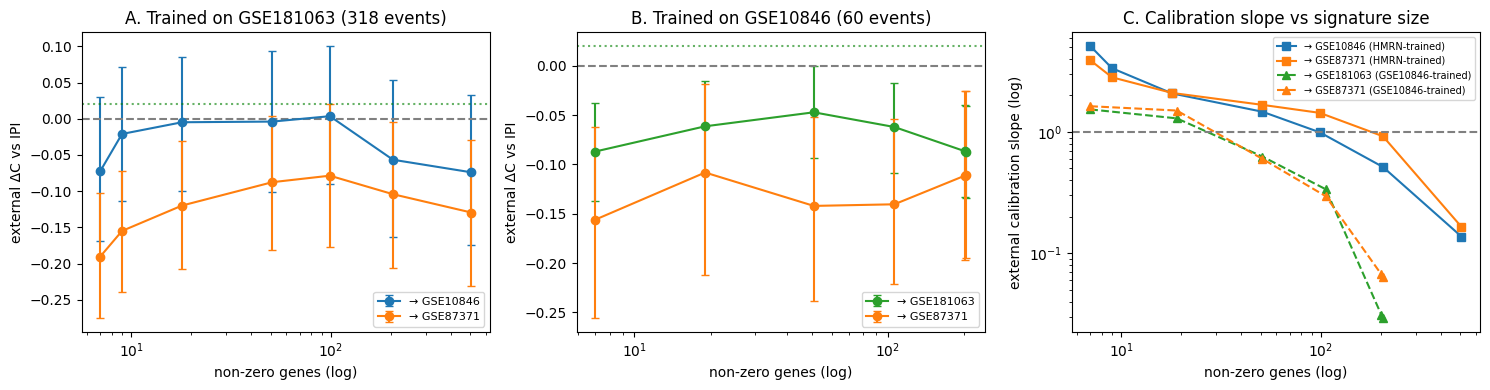

In [6]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
def panel(a,S,cohorts,title):
    for name,col in cohorts:
        a.errorbar(S["n_genes"],S[f"{name}_dC"],yerr=[S[f"{name}_dC"]-S[f"{name}_lo"],S[f"{name}_hi"]-S[f"{name}_dC"]],marker="o",label=f"→ {name}",color=col,capsize=3)
    a.axhline(0,color="gray",ls="--"); a.axhline(0.02,color="green",ls=":",alpha=.6); a.set_xscale("log")
    a.set_xlabel("non-zero genes (log)"); a.set_ylabel("external ΔC vs IPI"); a.set_title(title); a.legend(fontsize=8)
panel(ax[0],S1,[("GSE10846","C0"),("GSE87371","C1")],"A. Trained on GSE181063 (318 events)")
panel(ax[1],S2,[("GSE181063","C2"),("GSE87371","C1")],"B. Trained on GSE10846 (60 events)")
for name,col in [("GSE10846","C0"),("GSE87371","C1")]:
    ax[2].plot(S1["n_genes"],S1[f"{name}_slope"],marker="s",label=f"→ {name} (HMRN-trained)",color=col)
for name,col in [("GSE181063","C2"),("GSE87371","C1")]:
    ax[2].plot(S2["n_genes"],S2[f"{name}_slope"],marker="^",ls="--",label=f"→ {name} (GSE10846-trained)",color=col)
ax[2].axhline(1,color="gray",ls="--"); ax[2].set_xscale("log"); ax[2].set_yscale("log"); ax[2].set_xlabel("non-zero genes (log)")
ax[2].set_ylabel("external calibration slope (log)"); ax[2].set_title("C. Calibration slope vs signature size"); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.savefig("/kaggle/working/fig_signature_length_sweep.png",dpi=150,bbox_inches="tight"); plt.show()

## B2 — Cautionary analysis: path-end vs CV-tuned fit (supplement)

In [7]:
Xg=expr_tr.loc[common_genes,tr_ids].T; top=Xg.var().nlargest(2000).index; X_tr=StandardScaler().fit_transform(Xg[top])
pm,al,mc=cv_alpha(X_tr,y_tr); a_best=al[np.nanargmax(mc)]
m_end=CoxnetSurvivalAnalysis(l1_ratio=0.9,alpha_min_ratio=0.05,max_iter=100000).fit(X_tr,y_tr)           # path-end (as originally reported)
m_cv=CoxnetSurvivalAnalysis(l1_ratio=0.9,alphas=[a_best],max_iter=100000).fit(X_tr,y_tr)
Xh=StandardScaler().fit_transform(expr_val.loc[top,eval_ids].reindex(top).T)
e,t,ipi=ev["event"].astype(bool),ev["time_yrs"],ev["ipi_given"]
for nm,m in [("path-end (least regularized)",m_end),("CV-tuned",m_cv)]:
    p=m.predict(Xh); c,d,lo,hi=boot_generic(e,t,p,ipi)
    nz=(m.coef_[:,-1]!=0).sum() if m.coef_.ndim>1 else (m.coef_!=0).sum()
    print(f"{nm:30s} genes={nz:4d}  C={c:.3f}  dC={d:+.3f} [{lo:+.3f},{hi:+.3f}]  slope={slope(e,t,p):.2f}")

path-end (least regularized)   genes= 160  C=0.603  dC=-0.084 [-0.130,-0.038]  slope=0.08
CV-tuned                       genes=  27  C=0.631  dC=-0.056 [-0.103,-0.009]  slope=1.00


## B3 — Lenz reproduction figure + cross-platform implementation check

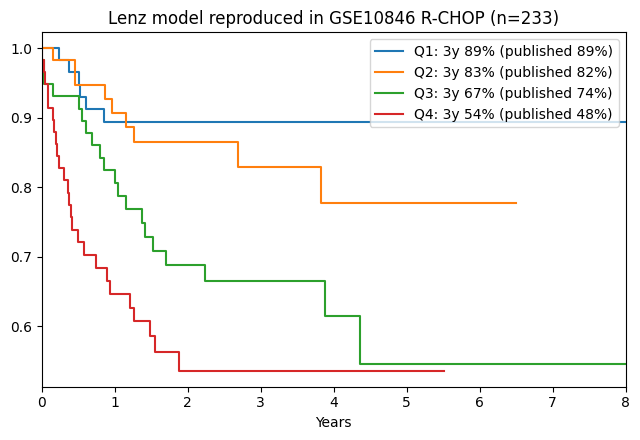

HMRN raw vs standardized Lenz score: Spearman rho = 0.998
  Lenz [raw] HMRN C=0.638 dC=-0.048 [-0.092,-0.003]
  Lenz [standardized] HMRN C=0.637 dC=-0.049 [-0.093,-0.004]


In [8]:
def resolve(genes,index):
    out=[]
    for g in genes:
        alt=LENZ_ALIASES.get(g,g)
        for c in (g,alt):
            if c is not None and c in index: out.append(c); break
    return out
def lenz_parts(expr_df,ids):
    return [expr_df.loc[resolve(gl,expr_df.index),ids].mean(axis=0) for gl in (GCB_SYMBOLS,STROMAL1_SYMBOLS,STROMAL2_SYMBOLS)]
def lenz_score(expr_df,ids,standardize=False):
    gcb,s1,s2=lenz_parts(expr_df,ids)
    if standardize: gcb,s1,s2=[(x-x.mean())/x.std() for x in (gcb,s1,s2)]
    return 8.11-0.419*gcb-1.015*s1+0.675*s2

# reproduction KM on GSE10846 R-CHOP with published 3-yr OS annotated
sc=lenz_score(expr_tr,tr_ids); q=pd.qcut(sc,4,labels=["Q1","Q2","Q3","Q4"]); pub={"Q1":89,"Q2":82,"Q3":74,"Q4":48}
fig,ax=plt.subplots(figsize=(6.5,4.5)); kmf=KaplanMeierFitter()
for lab in ["Q1","Q2","Q3","Q4"]:
    m=(q==lab).values; kmf.fit(tr["time_yrs"][m],tr["event"][m],label=f"{lab}: 3y {kmf.fit(tr['time_yrs'][m],tr['event'][m]).predict(3.0):.0%} (published {pub[lab]}%)"); kmf.plot_survival_function(ax=ax,ci_show=False)
ax.set_title("Lenz model reproduced in GSE10846 R-CHOP (n=233)"); ax.set_xlabel("Years"); ax.set_xlim(0,8)
plt.tight_layout(); plt.savefig("/kaggle/working/fig_lenz_reproduction.png",dpi=150,bbox_inches="tight"); plt.show()

# cross-platform check: raw vs standardized score in HMRN, and component correlations
raw=lenz_score(expr_val,eval_ids); std=lenz_score(expr_val,eval_ids,standardize=True)
from scipy.stats import spearmanr
print("HMRN raw vs standardized Lenz score: Spearman rho =", round(spearmanr(raw,std)[0],3))
e,t,ipi=ev["event"].astype(bool),ev["time_yrs"],ev["ipi_given"]
for nm,s in [("raw",raw),("standardized",std)]:
    c,d,lo,hi=boot_generic(e,t,s.values,ipi); print(f"  Lenz [{nm}] HMRN C={c:.3f} dC={d:+.3f} [{lo:+.3f},{hi:+.3f}]")

## B4 — Equivalence framing: does each model's CI exclude a clinically meaningful gain (ΔC ≥ 0.02)?

In [9]:
MCID=0.02
# assemble the final rows (HMRN eval set) — uses frozen models rebuilt above / from earlier notebooks
tc=tr["coo"].astype(str).str.upper()
ci_tr=pd.DataFrame({"abc":tc.str.contains("ABC").astype(float),"unc":(~tc.str.contains("ABC|GCB")).astype(float),"ipi":tr["ipi"]}).dropna()
m3=CoxPHSurvivalAnalysis().fit(ci_tr.values,Surv.from_arrays(tr.loc[ci_tr.index,"event"].astype(bool),tr.loc[ci_tr.index,"time_yrs"]))
vc=ev["coo"].astype(str).str.upper(); ci_v=pd.DataFrame({"abc":vc.eq("ABC").astype(float),"unc":(~vc.isin(["ABC","GCB"])).astype(float),"ipi":ev["ipi_given"]})
sc_tr_z=(sc-sc.mean())/sc.std(); Xl=pd.DataFrame({"lenz":sc_tr_z,"ipi":tr["ipi"]}).dropna()
m_li=CoxPHSurvivalAnalysis().fit(Xl.values,Surv.from_arrays(tr.loc[Xl.index,"event"].astype(bool),tr.loc[Xl.index,"time_yrs"]))
std_z=(std-std.mean())/std.std()
rows={"Genes-only (CV-tuned)":m_cv.predict(Xh),"Lenz model":std.values,"Lenz + IPI":m_li.predict(np.c_[std_z,ev["ipi_given"]]),"COO + IPI":m3.predict(ci_v.values)}
print(f"{'model':24s} {'dC':>7s} {'95% CI':>18s}   verdict (MCID={MCID})")
for nm,s in rows.items():
    c,d,lo,hi=boot_generic(e,t,s,ipi)
    verdict="gain ≥MCID excluded" if hi<MCID else ("gain ≥MCID supported" if lo>MCID else "inconclusive")
    print(f"{nm:24s} {d:+.3f}  [{lo:+.3f}, {hi:+.3f}]   {verdict}")

model                         dC             95% CI   verdict (MCID=0.02)
Genes-only (CV-tuned)    -0.056  [-0.103, -0.009]   gain ≥MCID excluded
Lenz model               -0.049  [-0.093, -0.004]   gain ≥MCID excluded
Lenz + IPI               +0.028  [-0.002, +0.056]   inconclusive
COO + IPI                +0.036  [+0.011, +0.061]   inconclusive


In [10]:
## B5 — Reverse genes (82-gene HMRN-trained score) + IPI: is expression redundant with IPI?
# rebuild the reverse model (identical to A2)
Xh_all=expr_val.loc[common_genes,val_ids].T; top_rev=Xh_all.var().nlargest(2000).index
X_rev=StandardScaler().fit_transform(Xh_all[top_rev])
pm_r,al_r,mc_r=cv_alpha(X_rev,y_h); a_r=al_r[np.nanargmax(mc_r)]
m_rev=CoxnetSurvivalAnalysis(l1_ratio=0.9,alphas=[a_r],max_iter=100000).fit(X_rev,y_h)
print("reverse model genes:",(m_rev.coef_.ravel()!=0).sum())

# genes+IPI combination weights fitted on HMRN (IPI-available subset), then FROZEN
h_ids=eval_ids
g_h=pd.Series(m_rev.predict(StandardScaler().fit_transform(expr_val.loc[top_rev,h_ids].T)),index=h_ids)
g_h_z=(g_h-g_h.mean())/g_h.std()
m_gi=CoxPHSurvivalAnalysis().fit(np.c_[g_h_z,ev["ipi_given"]],Surv.from_arrays(ev["event"].astype(bool),ev["time_yrs"]))
print("genes+IPI coefs (HMRN):",m_gi.coef_.round(3))

# also: COO + genes + IPI on HMRN, to test genes' increment over COO+IPI
vc=ev["coo"].astype(str).str.upper()
m_gci=CoxPHSurvivalAnalysis().fit(np.c_[g_h_z,vc.eq("ABC").astype(float),(~vc.isin(["ABC","GCB"])).astype(float),ev["ipi_given"]],
                                  Surv.from_arrays(ev["event"].astype(bool),ev["time_yrs"]))
print("genes+COO+IPI coefs (HMRN):",m_gci.coef_.round(3))

def apply_rev(texpr,tids,tdf,ipicol,coo_series=None):
    g=pd.Series(m_rev.predict(StandardScaler().fit_transform(texpr.reindex(top_rev).loc[:,tids].fillna(0).T)),index=tids)
    gz=(g-g.mean())/g.std(); ipi=tdf.loc[tids,ipicol]
    e,t=tdf.loc[tids,"event"].astype(bool),tdf.loc[tids,"time_yrs"]
    out={"genes only":g.values,"genes + IPI":m_gi.predict(np.c_[gz,ipi])}
    if coo_series is not None:
        cs=coo_series.loc[tids].astype(str).str.upper()
        out["genes + COO + IPI"]=m_gci.predict(np.c_[gz,cs.str.contains("ABC").astype(float),(~cs.str.contains("ABC|GCB|^GC$")).astype(float),ipi])
    return e,t,ipi,out

for cname,(texpr,tids,tdf,ipicol,coo) in {"GSE10846 R-CHOP":(expr_tr,g10,trdf,"ipi_given",tr["coo"]),
                                           "GSE87371":(expr3g,ids3,df3,"ipi_given",df3["coo"])}.items():
    e,t,ipi,out=apply_rev(texpr,tids,tdf,ipicol,coo)
    print(f"--- {cname} (n={len(tids)}) ---")
    for nm,s in out.items():
        c,d,lo,hi=boot_generic(e,t,s,ipi); print(f"  {nm:20s} C={c:.3f} (IPI {concordance_index_censored(e,t,ipi)[0]:.3f})  dC={d:+.3f} [{lo:+.3f},{hi:+.3f}]")

reverse model genes: 82
genes+IPI coefs (HMRN): [1.211 0.307]
genes+COO+IPI coefs (HMRN): [ 1.219 -0.029 -0.047  0.306]
--- GSE10846 R-CHOP (n=164) ---
  genes only           C=0.708 (IPI 0.699)  dC=+0.008 [-0.087,+0.101]
  genes + IPI          C=0.738 (IPI 0.699)  dC=+0.039 [-0.041,+0.118]
  genes + COO + IPI    C=0.737 (IPI 0.699)  dC=+0.037 [-0.042,+0.117]
--- GSE87371 (n=201) ---
  genes only           C=0.713 (IPI 0.787)  dC=-0.075 [-0.176,+0.021]
  genes + IPI          C=0.766 (IPI 0.787)  dC=-0.023 [-0.102,+0.053]
  genes + COO + IPI    C=0.765 (IPI 0.787)  dC=-0.024 [-0.103,+0.052]
